In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df=pd.read_csv("C:/Users/zinan/OneDrive/Documents/Datasets/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [132]:
df.shape

(1338, 7)

In [133]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [134]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [135]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [137]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [138]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [139]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

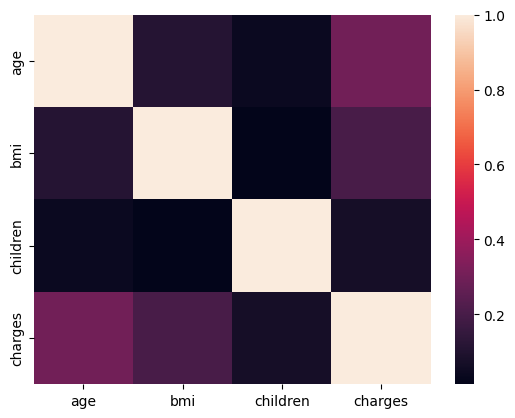

In [140]:
sns.heatmap(df.corr(numeric_only=True))

In [141]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [142]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [143]:
df.duplicated().sum()

np.int64(1)

In [144]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [145]:
df.drop_duplicates(inplace=True)

In [146]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='sex', ylabel='count'>

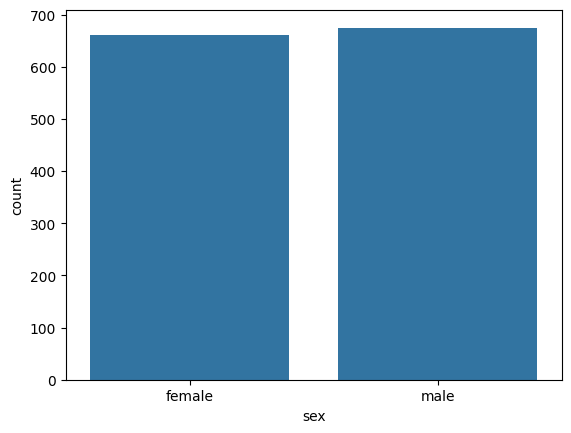

In [147]:
sns.countplot(x='sex',data=df)

In [148]:
df1=df['smoker'].value_counts()
df1

smoker
no     1063
yes     274
Name: count, dtype: int64

Text(0.5, 1.0, 'smokers counts')

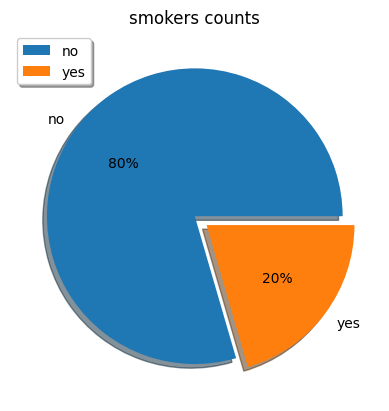

In [149]:
plt.pie(df1.values,labels=df1.index,explode=[0,0.1],shadow=True,autopct='%2.f%%')
plt.legend(loc='upper left',shadow=True)
plt.title('smokers counts')

<Axes: xlabel='region', ylabel='count'>

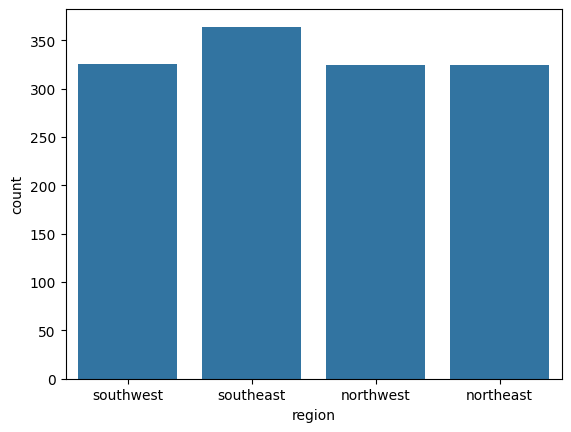

In [150]:
sns.countplot(x='region',data=df)

In [151]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [152]:
df2=pd.get_dummies(df[['sex','smoker']],drop_first=True,dtype=int)
df2

,sex_male,smoker_yes
0,0,1
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
1333,1,0
1334,0,0
1335,0,0
1336,0,0


In [153]:
dfe=pd.concat([df,df2],axis=1)
dfe

,age,sex,bmi,children,smoker,region,charges,sex_male,smoker_yes
0,19,female,27.900,0,yes,southwest,16884.92400,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,1,0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [154]:
dfe.drop(['children','sex','region','smoker'],axis=1,inplace=True)
dfe

,age,bmi,charges,sex_male,smoker_yes
0,19,27.900,16884.92400,0,1
1,18,33.770,1725.55230,1,0
2,28,33.000,4449.46200,1,0
3,33,22.705,21984.47061,1,0
4,32,28.880,3866.85520,1,0
...,...,...,...,...,...
1333,50,30.970,10600.54830,1,0
1334,18,31.920,2205.98080,0,0
1335,18,36.850,1629.83350,0,0
1336,21,25.800,2007.94500,0,0


In [155]:
dfe.dtypes

age             int64
bmi           float64
charges       float64
sex_male        int64
smoker_yes      int64
dtype: object

In [156]:
dfe.isna().sum()

age           0
bmi           0
charges       0
sex_male      0
smoker_yes    0
dtype: int64

In [157]:
dfe.duplicated().sum()

np.int64(0)

In [158]:
x=dfe.drop('charges',axis=1)
y=dfe['charges']

In [159]:
x

,age,bmi,sex_male,smoker_yes
0,19,27.900,0,1
1,18,33.770,1,0
2,28,33.000,1,0
3,33,22.705,1,0
4,32,28.880,1,0
...,...,...,...,...
1333,50,30.970,1,0
1334,18,31.920,0,0
1335,18,36.850,0,0
1336,21,25.800,0,0


In [160]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1337, dtype: float64

<Axes: xlabel='age', ylabel='charges'>

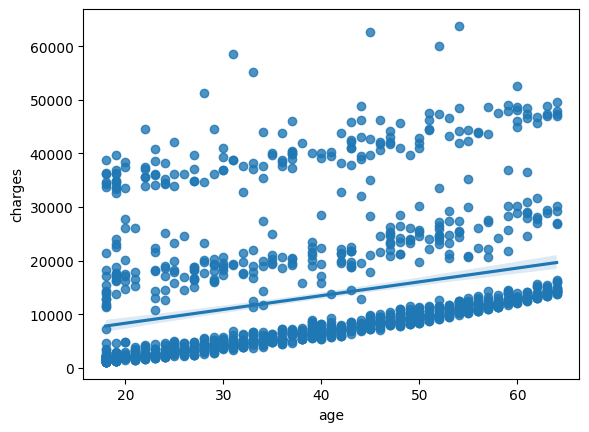

In [161]:
sns.regplot(x='age',y=y,data=dfe)

<Axes: xlabel='bmi', ylabel='charges'>

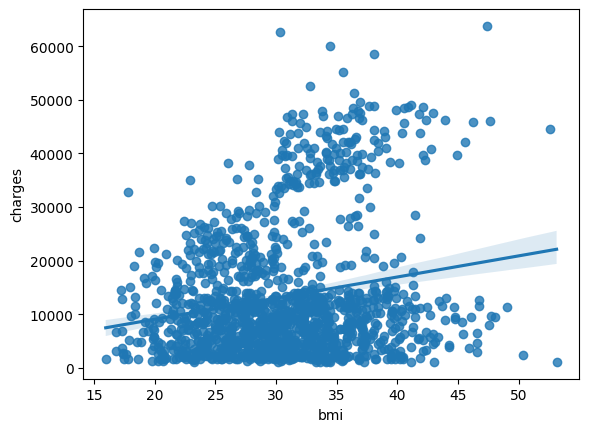

In [162]:
sns.regplot(x='bmi',y=y,data=df)

<Axes: xlabel='sex_male', ylabel='charges'>

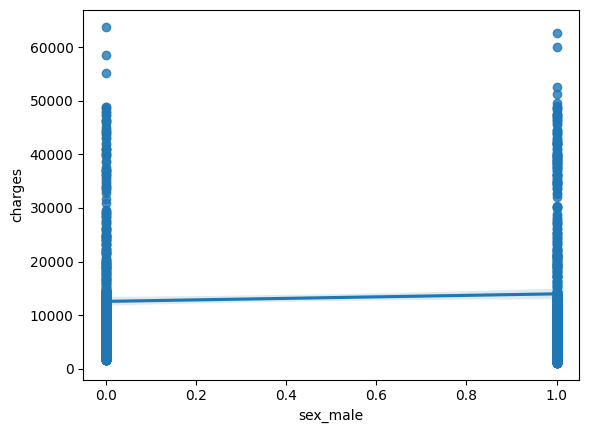

In [163]:
sns.regplot(x='sex_male',y=y,data=dfe)

<Axes: xlabel='smoker_yes', ylabel='charges'>

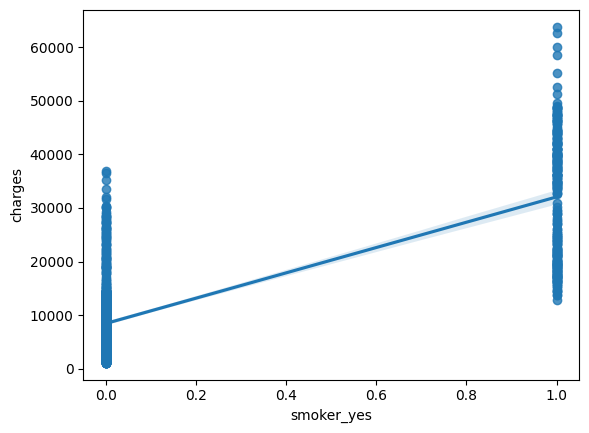

In [164]:
sns.regplot(x='smoker_yes',y=y,data=dfe)

In [165]:
from sklearn.feature_selection import SelectKBest,f_regression
chi2_selector=SelectKBest(score_func=f_regression,k='all')
chi2_selector.fit(x,y)
score=chi2_selector.scores_
feature_score=pd.DataFrame({
    "feature":x.columns,
    "scores":score
})
feature_score

,feature,scores
0,age,130.402971
1,bmi,54.702715
2,sex_male,4.513038
3,smoker_yes,2175.736863


In [167]:
feature_score_sort=feature_score.sort_values('scores',ascending=False)
feature_score_sort

,feature,scores
3,smoker_yes,2175.736863
0,age,130.402971
1,bmi,54.702715
2,sex_male,4.513038


(array([0, 1, 2, 3]),
 [Text(0, 0, 'smoker_yes'),
  Text(1, 0, 'age'),
  Text(2, 0, 'bmi'),
  Text(3, 0, 'sex_male')])

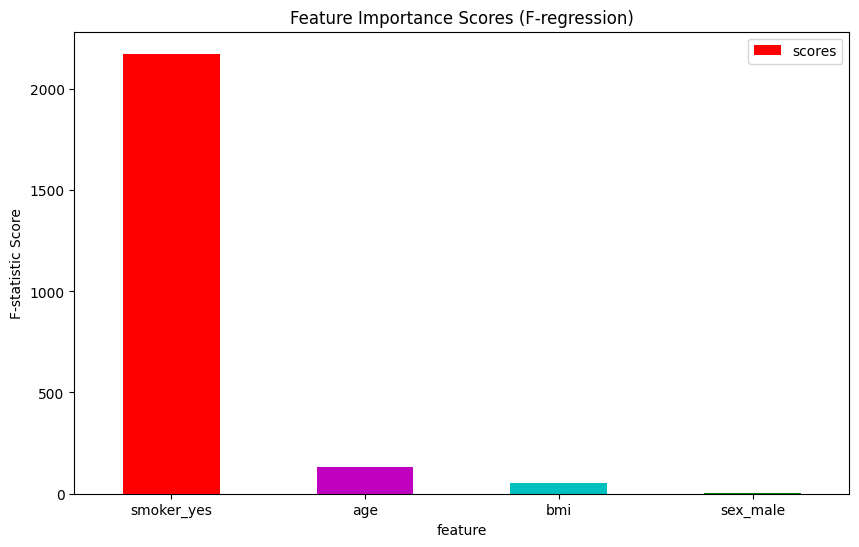

In [173]:
feature_score_sort.plot(x='feature',y='scores',kind="bar",figsize=(10,6),color=['r','m','c','g'])
plt.title('Feature Importance Scores (F-regression)')
plt.ylabel('F-statistic Score')
plt.xticks(rotation=0)

In [174]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)
x_train

,age,bmi,sex_male,smoker_yes
520,50,27.360,0,0
575,58,27.170,0,0
770,61,36.100,1,0
314,27,31.400,0,1
426,38,27.265,0,0
...,...,...,...,...
716,49,22.610,0,0
906,27,32.585,1,0
1097,22,33.770,1,0
235,40,22.220,0,1


In [175]:
x_test

,age,bmi,sex_male,smoker_yes
629,44,38.950,0,1
1087,57,31.540,1,0
283,55,32.395,0,0
790,39,41.800,0,0
594,41,40.260,1,0
...,...,...,...,...
924,43,23.200,1,0
873,43,30.100,1,0
731,53,21.400,1,0
363,21,26.400,0,0


In [176]:
y_train

520     25656.57526
575     12222.89830
770     27941.28758
314     34838.87300
426      6555.07035
           ...     
716      9566.99090
906      4846.92015
1097     1674.63230
235     19444.26580
1062    48970.24760
Name: charges, Length: 935, dtype: float64

In [177]:
y_test

629     42983.45850
1087    11353.22760
283     11879.10405
790      5662.22500
594      5709.16440
           ...     
924      6250.43500
873      6849.02600
731     10065.41300
363      2597.77900
10       2721.32080
Name: charges, Length: 402, dtype: float64

In [179]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([ 3.65029771e+04,  1.32044522e+04,  1.35157618e+04,  1.28718219e+04,
        1.23049364e+04,  2.39711144e+03,  5.84142958e+03,  1.08928437e+04,
        1.05967348e+04,  3.26095330e+04,  1.18791081e+04,  4.38505058e+03,
        1.11737520e+04,  8.22634220e+03,  4.15983540e+03,  1.39351407e+04,
        3.67861382e+03,  3.09159011e+04,  1.61261296e+04,  1.55527989e+04,
        6.55339909e+03,  1.94029958e+04,  9.44291403e+03,  9.96608545e+03,
        6.14940814e+03,  3.53999254e+04,  8.01102275e+03,  3.95811635e+04,
        5.83195209e+03,  3.92783060e+03,  1.57957649e+04,  5.13162029e+03,
        4.31189535e+03,  8.98872221e+03,  3.52210479e+03,  5.00728891e+03,
        3.09958641e+04,  1.23438763e+04,  1.24081567e+04,  8.34257652e+03,
        3.27425154e+04,  4.12804250e+01,  1.05147381e+04,  3.42858709e+04,
        1.86677053e+04,  1.28843458e+04,  1.39662003e+04,  3.90538058e+03,
        7.12534638e+03,  1.02793203e+04,  1.42538901e+04,  1.25102477e+04,
        1.20734400e+04,  

In [180]:
y_test

629     42983.45850
1087    11353.22760
283     11879.10405
790      5662.22500
594      5709.16440
           ...     
924      6250.43500
873      6849.02600
731     10065.41300
363      2597.77900
10       2721.32080
Name: charges, Length: 402, dtype: float64

In [181]:
df4=pd.DataFrame({
    'actual_value':y_test,
    'predicted_value':y_pred,
    'difference':y_test-y_pred
})
df4

,actual_value,predicted_value,difference
629,42983.45850,36502.977085,6480.481415
1087,11353.22760,13204.452225,-1851.224625
283,11879.10405,13515.761786,-1636.657736
790,5662.22500,12871.821912,-7209.596912
594,5709.16440,12304.936407,-6595.772007
...,...,...,...
924,6250.43500,6458.911912,-208.476912
873,6849.02600,9033.326527,-2184.300527
731,10065.41300,8382.937319,1682.475681
363,2597.77900,2453.925681,143.853319


In [184]:
px.scatter(df4,x='actual_value',y='predicted_value',color='difference')

In [185]:
from sklearn.metrics import mean_absolute_percentage_error,r2_score
mape=mean_absolute_percentage_error(y_test,y_pred)
mape

0.48550885783754727

In [186]:
score=r2_score(y_test,y_pred)*100
score

73.3182972487275